# Experiment 1
## Baseline LSTM for IMDB Sentiment Classification

This notebook trains a standard LSTM model that will serve as the baseline for BN-LSTM and R-ABNN-LSTM experiments.

In [5]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

In [6]:
import time
import matplotlib.pyplot as plt

In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [7]:
import sys
print(sys.executable)

/usr/bin/python3


In [8]:
import platform
print(platform.platform())

Linux-6.6.122+-x86_64-with-glibc2.35


In [9]:
import google.colab
print("Running in Colab")

Running in Colab


In [10]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [11]:
import sys
import platform

print("Python:", sys.executable)
print("Platform:", platform.platform())

try:
    import google.colab
    print("Google Colab: Yes")
except:
    print("Google Colab: No")

Python: /usr/bin/python3
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Google Colab: Yes


In [13]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
# Set Project Directory
PROJECT_DIR = "/content/drive/MyDrive/R-ABNN-LSTM"

os.chdir(PROJECT_DIR)

print(os.getcwd())

/content/drive/MyDrive/R-ABNN-LSTM


In [15]:
import os
print(os.listdir("checkpoints"))

['vocab.pt', 'train_dataset.pt', 'test_dataset.pt', 'train_texts.pt', 'train_labels.pt', 'test_texts.pt', 'test_labels.pt', 'lstm.pth']


In [16]:
# Load Processed Data
vocab = torch.load(
    "checkpoints/vocab.pt"
)

train_texts = torch.load(
    "checkpoints/train_texts.pt"
)

train_labels = torch.load(
    "checkpoints/train_labels.pt"
)

test_texts = torch.load(
    "checkpoints/test_texts.pt"
)

test_labels = torch.load(
    "checkpoints/test_labels.pt"
)

In [17]:
# Verify Data
print(train_texts.shape)
print(train_labels.shape)

print(test_texts.shape)
print(test_labels.shape)

torch.Size([25000, 200])
torch.Size([25000])
torch.Size([25000, 200])
torch.Size([25000])


In [18]:
# Create Datasets
train_dataset = TensorDataset(
    train_texts,
    train_labels
)

test_dataset = TensorDataset(
    test_texts,
    test_labels
)

In [19]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [20]:
# Define Model
class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        output_dim
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            output_dim
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(
            embedded
        )

        hidden = hidden[-1]

        logits = self.fc(hidden)

        return logits

In [24]:

BATCH_SIZE = 64

trainloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

testloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(type(trainloader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [22]:
print(type(train_texts))
print(type(train_labels))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [23]:
train_dataset = TensorDataset(
    train_texts,
    train_labels
)

test_dataset = TensorDataset(
    test_texts,
    test_labels
)

print(len(train_dataset))
print(len(test_dataset))

25000
25000


In [25]:
batch = next(iter(trainloader))

inputs, labels = batch

print(inputs.shape)
print(labels.shape)

torch.Size([64, 200])
torch.Size([64])


In [26]:
# Hyperparameters
VOCAB_SIZE = len(vocab)

EMBED_DIM = 128

HIDDEN_DIM = 128

OUTPUT_DIM = 2

LEARNING_RATE = 1e-3

EPOCHS = 5

In [27]:
# Create Model
model = LSTMClassifier(
    VOCAB_SIZE,
    EMBED_DIM,
    HIDDEN_DIM,
    OUTPUT_DIM
)

model = model.to(device)

print(model)

LSTMClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [28]:
# Loss Function
criterion = nn.CrossEntropyLoss()

In [29]:
# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [31]:
# TRAINING FUNCTIONS
def train_epoch():

    model.train()

    running_loss = 0

    for inputs, labels in trainloader:

        inputs = inputs.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(trainloader)

In [32]:
def evaluate():

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for inputs, labels in testloader:

            inputs = inputs.to(device)

            labels = labels.to(device)

            outputs = model(inputs)

            preds = outputs.argmax(1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total

In [33]:
# TRAINING
train_losses = []

start_time = time.time()

for epoch in range(EPOCHS):

    loss = train_epoch()

    accuracy = evaluate()

    train_losses.append(loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Loss: {loss:.4f}"
        f" | Accuracy: {accuracy:.2f}%"
    )

end_time = time.time()

Epoch 1/5 | Loss: 0.6934 | Accuracy: 50.07%
Epoch 2/5 | Loss: 0.6735 | Accuracy: 54.87%
Epoch 3/5 | Loss: 0.6649 | Accuracy: 52.52%
Epoch 4/5 | Loss: 0.6312 | Accuracy: 53.16%
Epoch 5/5 | Loss: 0.5879 | Accuracy: 51.99%


In [34]:
# Training Time
print(
    f"Training Time: "
    f"{end_time-start_time:.2f} seconds"
)

Training Time: 19.23 seconds


In [35]:
# SAVE MODEL
os.makedirs(
    "checkpoints",
    exist_ok=True
)

torch.save(
    model.state_dict(),
    "checkpoints/lstm.pth"
)

print("Model saved.")

Model saved.


In [36]:
# FINAL ACCURACY
final_accuracy = evaluate()

print(
    f"Final Accuracy: "
    f"{final_accuracy:.2f}%"
)

Final Accuracy: 51.99%


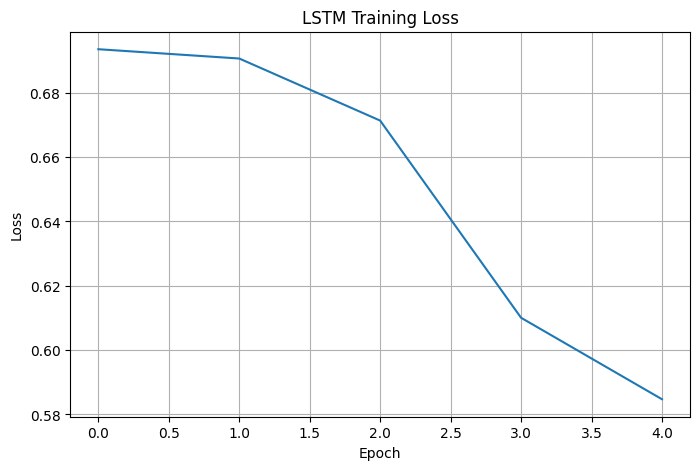

In [52]:
# PLOT LOSS
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("LSTM Training Loss")

plt.grid()

plt.show()

In [53]:
# EXPERIMENT LOG
with open(
    "thesis_notes/experiment_log.md",
    "a"
) as f:

    f.write(
        f"""

Baseline LSTM Results

Accuracy:
{final_accuracy:.2f}

Training Time:
{end_time-start_time:.2f}

"""
    )

print("Results logged.")

Results logged.


In [55]:
import torch

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU available")

No GPU available
